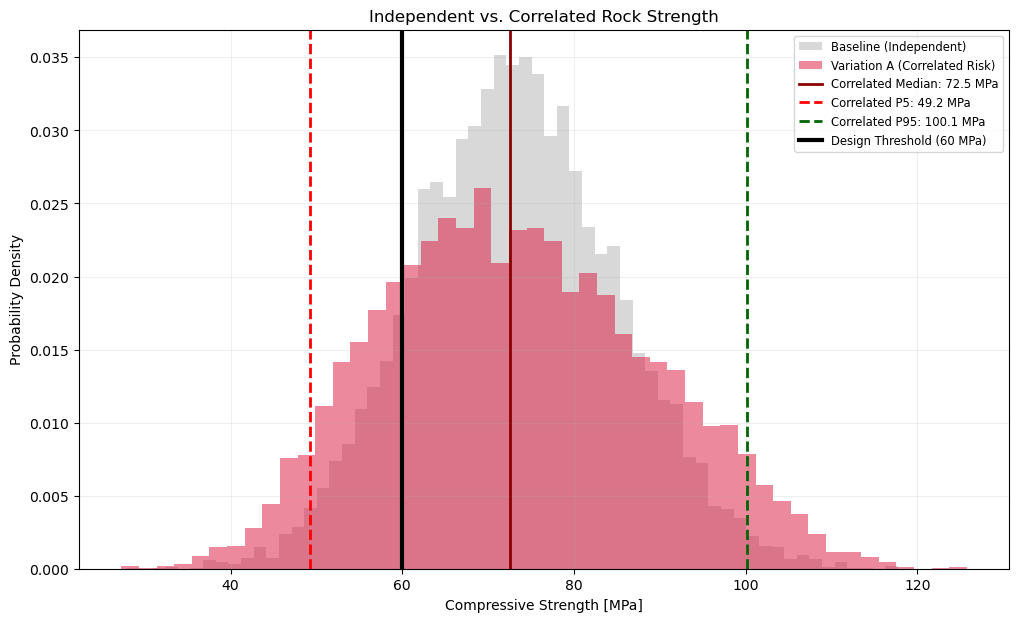

--- RISK AUDIT ---
Baseline Prob. of Failure: 12.69%
Correlated Prob. of Failure: 21.39%
COMMERCIAL IMPACT: Sorting increased failure probability by 8.70%

Rs [375000. 375000. 375000. ... 375000. 375000. 375000.]
DISTRIBUTION AUDIT: {150000.0: 4353, 375000.0: 5647}


In [ ]:
from core.geology import Hrock
from core.tunnel import TunnelSection, TunnelSupport


import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

# --- 1. DATA GENERATION ---
ucs_samples = np.random.normal(loc=50, scale=10, size=10000)
fa_samples = 20 + (np.random.beta(a=1, b=1, size=10000) * 20)
fd_samples = 25 + (np.random.beta(a=5, b=5, size=10000) * 10)
confinement = 5 + (np.random.beta(5, 5, 10000) * 5)

# (Independent Risk)
rock_base = Hrock(ucs=ucs_samples.copy(), fa=fa_samples.copy(), fd=fd_samples.copy())
strength_base = rock_base.estimated_strength(confinement=confinement)


# Forensic Intent: Force the tails to align. Worst UCS + Worst Friction = True Himalayan Criticality.
ucs_samples.sort()
fa_samples.sort()
fd_samples.sort()

rock_correlated = Hrock(ucs=ucs_samples, fa=fa_samples, fd=fd_samples)
strength_correlated = rock_correlated.estimated_strength(confinement=confinement)


plt.figure(figsize=(12, 7))

# Plotting both for comparison
plt.hist(strength_base, bins='fd', color='gray', alpha=0.3, density=True, label="Baseline (Independent)")
plt.hist(strength_correlated, bins='fd', color='crimson', alpha=0.5, density=True, label="Variation A (Correlated Risk)")

# Centrality Anchor (Median of Correlated)
median_val = np.median(strength_correlated)
plt.axvline(median_val, color='darkred', lw=2, label=f"Correlated Median: {median_val:.1f} MPa") #type:ignore

# Uncertainty Bracket (P5 and P95 of Correlated)
p5 = np.percentile(strength_correlated, 5)
p95 = np.percentile(strength_correlated, 95)
plt.axvline(p5, color='red', linestyle='--', lw=2, label=f"Correlated P5: {p5:.1f} MPa") #type:ignore

plt.axvline(p95, color='darkgreen', linestyle='--', lw=2, label=f"Correlated P95: {p95:.1f} MPa") #type:ignore


# Crisis Line
design_threshold = 60
plt.axvline(design_threshold, color='black', lw=3, label=f"Design Threshold ({design_threshold} MPa)")

plt.title("Independent vs. Correlated Rock Strength")
plt.xlabel("Compressive Strength [MPa]")
plt.ylabel("Probability Density")
plt.legend(loc='upper right', fontsize='small')
plt.grid(True, alpha=0.2)
plt.show()

# Forensic Output
p_fail_base = np.mean(strength_base < design_threshold) * 100
p_fail_corr = np.mean(strength_correlated < design_threshold) * 100

print("--- RISK AUDIT ---")
print(f"Baseline Prob. of Failure: {p_fail_base:.2f}%")
print(f"Correlated Prob. of Failure: {p_fail_corr:.2f}%")
print(f"COMMERCIAL IMPACT: Sorting increased failure probability by {p_fail_corr - p_fail_base:.2f}%")

# since low ucs rocks tend to have low fa, they are correlated
# and since its natural, more likely we encounter such and if we dont consider
# more likely we underestimate our probability

base_support = TunnelSupport(cost_per_m=1500) #usd
base_tunnel = TunnelSection("first", geology=rock_base, support=base_support, fos=1.5)



#100m, 50mpa

costs =  (base_tunnel.probabilistic_cost(length=100, induced_stress=50, confinement=confinement))

# once we start naming argumenets(keywords), every subsequent arguements must also be named




#uni = np.unique(costs)
#print(f"Unique Costs: {uni}")


#for i in range(len(uni)):
 #   print(np.sum(costs==uni[i]))

unique_costs, counts = np.unique(costs, return_counts=True)

risk_profile = {float(cost): int(count) for cost, count in zip(unique_costs, counts)}

print(f"DISTRIBUTION AUDIT: {risk_profile}")
